In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [3]:
from GridMaze.analysis.movement import velocity as vel

In [5]:
pop_velocity_tuning = vel.get_population_velocity_summary(verbose=False)

clusters.movementMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.movementMetrics.parquet not found for m8.2022-07-26.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze


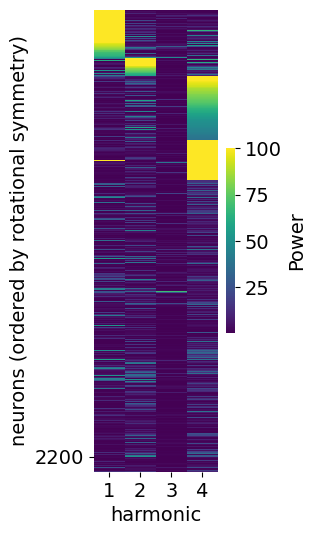

In [7]:
reload(vel)
f, ax = plt.subplots(1, 1, figsize=(2, 6))
vel.plot_velocity_population_symmetry_heatmap(pop_velocity_tuning, n_clusters=8, vmax=100, min_ordering_power=30, ax=ax)

In [19]:
from GridMaze.analysis.core import get_clusters as gc

# look at some illustrative single cells
example_clusters = [
    # "m6.2022-07-04.maze_cluster66",  # velocity tuned
    # "m2.2022-06-30.maze_cluster33",  # 4sym off axis
    # "m6.2022-06-23.maze_cluster96",  #  4sym on axis
    # "m3.2022-07-29.maze_cluster91",  # velocity
    # "m3.2022-07-15.maze_cluster62",  # 4sym off axis
    # "m3.2022-07-05.maze_cluster121",  # speed
    # "m2.2022-07-26.maze_cluster74",  # speed slow
    # "m3.2022-07-15.maze_cluster65",  # speed
    "m3.2022-07-19.maze_cluster0",  # velocity
    "m3.2022-07-11.maze_cluster63",  # 2way sym
    "m3.2022-07-05.maze_cluster43",  # 2way sym
    "m3.2022-07-15.maze_cluster135",  # 4sym on axis
    "m2.2022-06-28.maze_cluster10",  # 4way off axis
    "m2.2022-06-29.maze_cluster63",  # speed ring
    "m2.2022-07-19.maze_cluster140",  # speed ring
    "m4.2022-07-01.maze_cluster59",  # speed
]

m3.2022-07-19.maze_cluster0
m3.2022-07-11.maze_cluster63
m3.2022-07-05.maze_cluster43
m3.2022-07-15.maze_cluster135
m2.2022-06-28.maze_cluster10
m2.2022-06-29.maze_cluster63
m2.2022-07-19.maze_cluster140
m4.2022-07-01.maze_cluster59


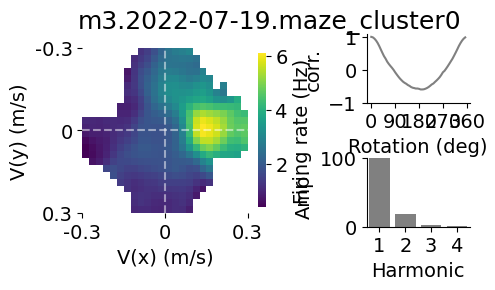

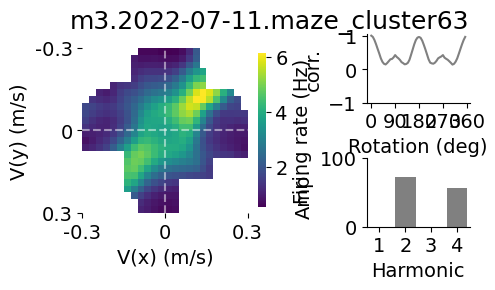

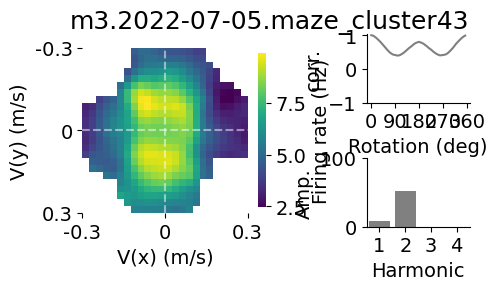

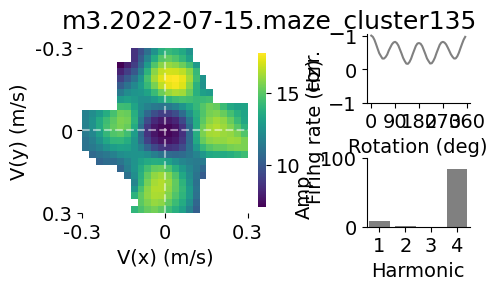

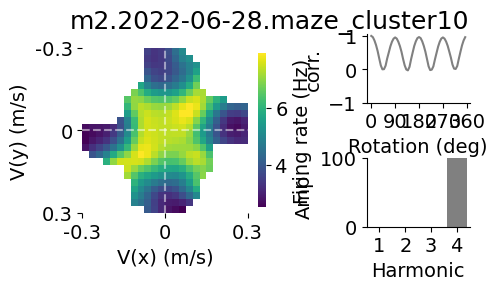

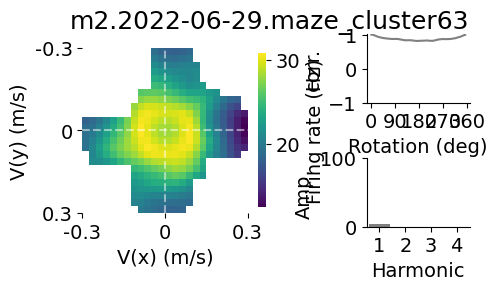

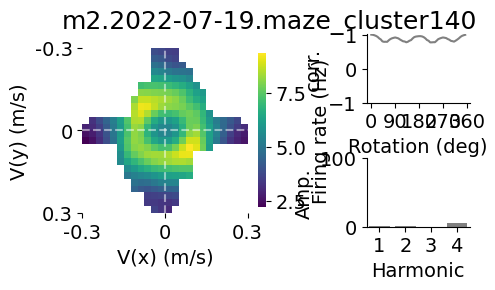

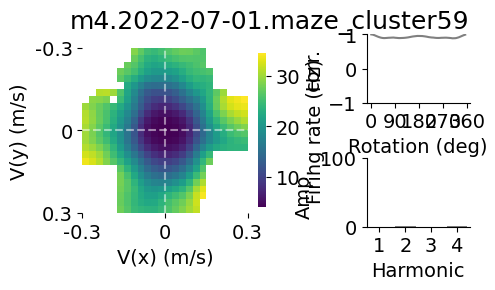

In [20]:
for cuID in example_clusters:
    print(cuID)
    Cluster = gc.get_cluster(cluster_unique_ID=cuID)
    fig = plt.figure(figsize=(5, 2.5), clear=True)
    gsc = GridSpec(2, 2, figure=fig, width_ratios=[2, 1], wspace=0.5, hspace=0.8)
    ax1 = fig.add_subplot(gsc[0:2, 0])  # v heatmap
    ax2 = fig.add_subplot(gsc[0, 1])  # rot corr
    ax3 = fig.add_subplot(gsc[1, 1])  # harmonics
    Cluster.plot_tuning(feature="velocity", feature_kwargs={"with_symmetry": True}, ax=(ax1, ax2, ax3))
    fig.suptitle(cuID)